In [ ]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'road-traffic-accidents:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F1145928%2F3095352%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240828%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240828T093050Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D28b1b90b24e18d9e98a42a322dc2902c038cbbbc740b2c9593f3c6aea4c2c5432ee89ea98067854274bfbf8497d3781a5ed07f71f3cd6e18f1488dcea3306e4919973ef9b633a33ff6872e2ff48a67d6166e7d83a6a65a354c4ea9035953fc5bb48a632c1e40a135a0f5864d1c55b3f31164371ac668dc347a67aa7ec73cf0fe5c686f6c60449e705c95ac87cd101794a6ac2bde531dc904f2fd7156cedce6f96b1139257996f57dc7efbabc75cb31aeae88827165275851e33003557a43227e1886dfdc1a67c522c97e585a74ae740e2abe1066f97b038f1a1b91b34cea9c53b33b32a0de2646fde0a9fdf36afaaa6d50c3f612c60af36bfcbdb8bfe57cc5c9'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += le non(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')

[==================================================] 460895 bytes downloaded
Downloaded and uncompressed: road-traffic-accidents
Data source import complete.


# Observatory Road Accident

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import re
from joblib import dump

In [ ]:
# Load the dataset
file_path = '/kaggle/input/road-traffic-accidents/RTA Dataset.csv'
dataset = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("Data Head:")
dataset.head()
# print(data.head())

Data Head:


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [ ]:
dataset.columns

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [ ]:
# Drop unnecessary columns
columns_to_drop = columns_to_drop = [
    'Time',
    'Vehicle_driver_relation',
    'Casualty_class',
    'Sex_of_casualty',
    'Age_band_of_casualty',
    'Casualty_severity',
    'Work_of_casuality',
    'Fitness_of_casuality',
    'Pedestrian_movement'
]

dataset = dataset.drop(columns=columns_to_drop)

In [ ]:
# Fill missing values if necessary (can be done with mode, mean, etc.)
dataset.fillna(dataset.mode().iloc[0], inplace=True)

In [ ]:
dataset.columns

Index(['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Driving_experience', 'Type_of_vehicle',
       'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle',
       'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment',
       'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions',
       'Light_conditions', 'Weather_conditions', 'Type_of_collision',
       'Number_of_vehicles_involved', 'Number_of_casualties',
       'Vehicle_movement', 'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [ ]:
dataset['Day_of_week'].unique()

array(['Monday', 'Sunday', 'Friday', 'Wednesday', 'Saturday', 'Thursday',
       'Tuesday'], dtype=object)

In [ ]:
dataset['Accident_severity'].unique()

array(['Slight Injury', 'Serious Injury', 'Fatal injury'], dtype=object)

In [ ]:
# Display basic information about the dataset
print("\nData Info:")
print(dataset.info())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Day_of_week                  12316 non-null  object
 1   Age_band_of_driver           12316 non-null  object
 2   Sex_of_driver                12316 non-null  object
 3   Educational_level            12316 non-null  object
 4   Driving_experience           12316 non-null  object
 5   Type_of_vehicle              12316 non-null  object
 6   Owner_of_vehicle             12316 non-null  object
 7   Service_year_of_vehicle      12316 non-null  object
 8   Defect_of_vehicle            12316 non-null  object
 9   Area_accident_occured        12316 non-null  object
 10  Lanes_or_Medians             12316 non-null  object
 11  Road_allignment              12316 non-null  object
 12  Types_of_Junction            12316 non-null  object
 13  Road_surface_type  

In [ ]:
# Check for missing values
print("\nMissing Values:")
print(dataset.isnull().sum())


Missing Values:
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Educational_level              0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Service_year_of_vehicle        0
Defect_of_vehicle              0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Cause_of_accident              0
Accident_severity              0
dtype: int64


In [ ]:
dataset.count()

,0
Day_of_week,12316
Age_band_of_driver,12316
Sex_of_driver,12316
Educational_level,12316
Driving_experience,12316
Type_of_vehicle,12316
Owner_of_vehicle,12316
Service_year_of_vehicle,12316
Defect_of_vehicle,12316
Area_accident_occured,12316


In [ ]:
dataset.shape

(12316, 23)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Day_of_week                  12316 non-null  object
 1   Age_band_of_driver           12316 non-null  object
 2   Sex_of_driver                12316 non-null  object
 3   Educational_level            12316 non-null  object
 4   Driving_experience           12316 non-null  object
 5   Type_of_vehicle              12316 non-null  object
 6   Owner_of_vehicle             12316 non-null  object
 7   Service_year_of_vehicle      12316 non-null  object
 8   Defect_of_vehicle            12316 non-null  object
 9   Area_accident_occured        12316 non-null  object
 10  Lanes_or_Medians             12316 non-null  object
 11  Road_allignment              12316 non-null  object
 12  Types_of_Junction            12316 non-null  object
 13  Road_surface_type            12

In [ ]:
dataset.columns

Index(['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Driving_experience', 'Type_of_vehicle',
       'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle',
       'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment',
       'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions',
       'Light_conditions', 'Weather_conditions', 'Type_of_collision',
       'Number_of_vehicles_involved', 'Number_of_casualties',
       'Vehicle_movement', 'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [ ]:

# Features to one-hot encode
one_hot_features =  [
    'Day_of_week',
    'Sex_of_driver',
    'Educational_level',
    'Type_of_vehicle',
    'Owner_of_vehicle',
    'Defect_of_vehicle',
    'Area_accident_occured',
    'Lanes_or_Medians',
    'Road_allignment',
    'Types_of_Junction',
    'Road_surface_type',
    'Road_surface_conditions',
    'Light_conditions',
    'Weather_conditions',
    'Type_of_collision',
    'Vehicle_movement',
    'Cause_of_accident'
]
# # One-hot encode these features
# dataset = pd.get_dummies(dataset, columns=one_hot_features, drop_first=True)

# One-hot encode these features
# one_hot_encoder = OneHotEncoder(drop='first', sparse=False)
one_hot_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
one_hot_encoded = one_hot_encoder.fit_transform(dataset[one_hot_features])

# Create a DataFrame with the one-hot encoded columns
one_hot_encoded_df = pd.DataFrame(one_hot_encoded, columns=one_hot_encoder.get_feature_names_out(one_hot_features))

# Drop the original one-hot encoded columns and concatenate the new ones
dataset = dataset.drop(columns=one_hot_features)
dataset = pd.concat([dataset, one_hot_encoded_df], axis=1)

# Features to label encode
label_encode_features = [
    'Age_band_of_driver',
    'Driving_experience',
    'Service_year_of_vehicle',
    'Accident_severity'
]

# Label encode these features
label_encoders = {}
for column in label_encode_features:
    le = LabelEncoder()
    dataset[column] = le.fit_transform(dataset[column])
    label_encoders[column] = le


numerical_columns = [
    'Number_of_vehicles_involved',
    'Number_of_casualties'
]


scaler = StandardScaler()

# Scale numerical columns
dataset[numerical_columns] = scaler.fit_transform(dataset[numerical_columns])


In [ ]:
dataset.head()

,Age_band_of_driver,Driving_experience,Service_year_of_vehicle,Number_of_vehicles_involved,Number_of_casualties,Accident_severity,Day_of_week_Monday,Day_of_week_Saturday,Day_of_week_Sunday,Day_of_week_Thursday,...,Cause_of_accident_No distancing,Cause_of_accident_No priority to pedestrian,Cause_of_accident_No priority to vehicle,Cause_of_accident_Other,Cause_of_accident_Overloading,Cause_of_accident_Overspeed,Cause_of_accident_Overtaking,Cause_of_accident_Overturning,Cause_of_accident_Turnover,Cause_of_accident_Unknown
0,0,0,3,-0.059061,0.448649,2,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,3,2,-0.059061,0.448649,2,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0,0,5,-0.059061,0.448649,1,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,2,5,-0.059061,0.448649,2,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,1,2,-0.059061,0.448649,2,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


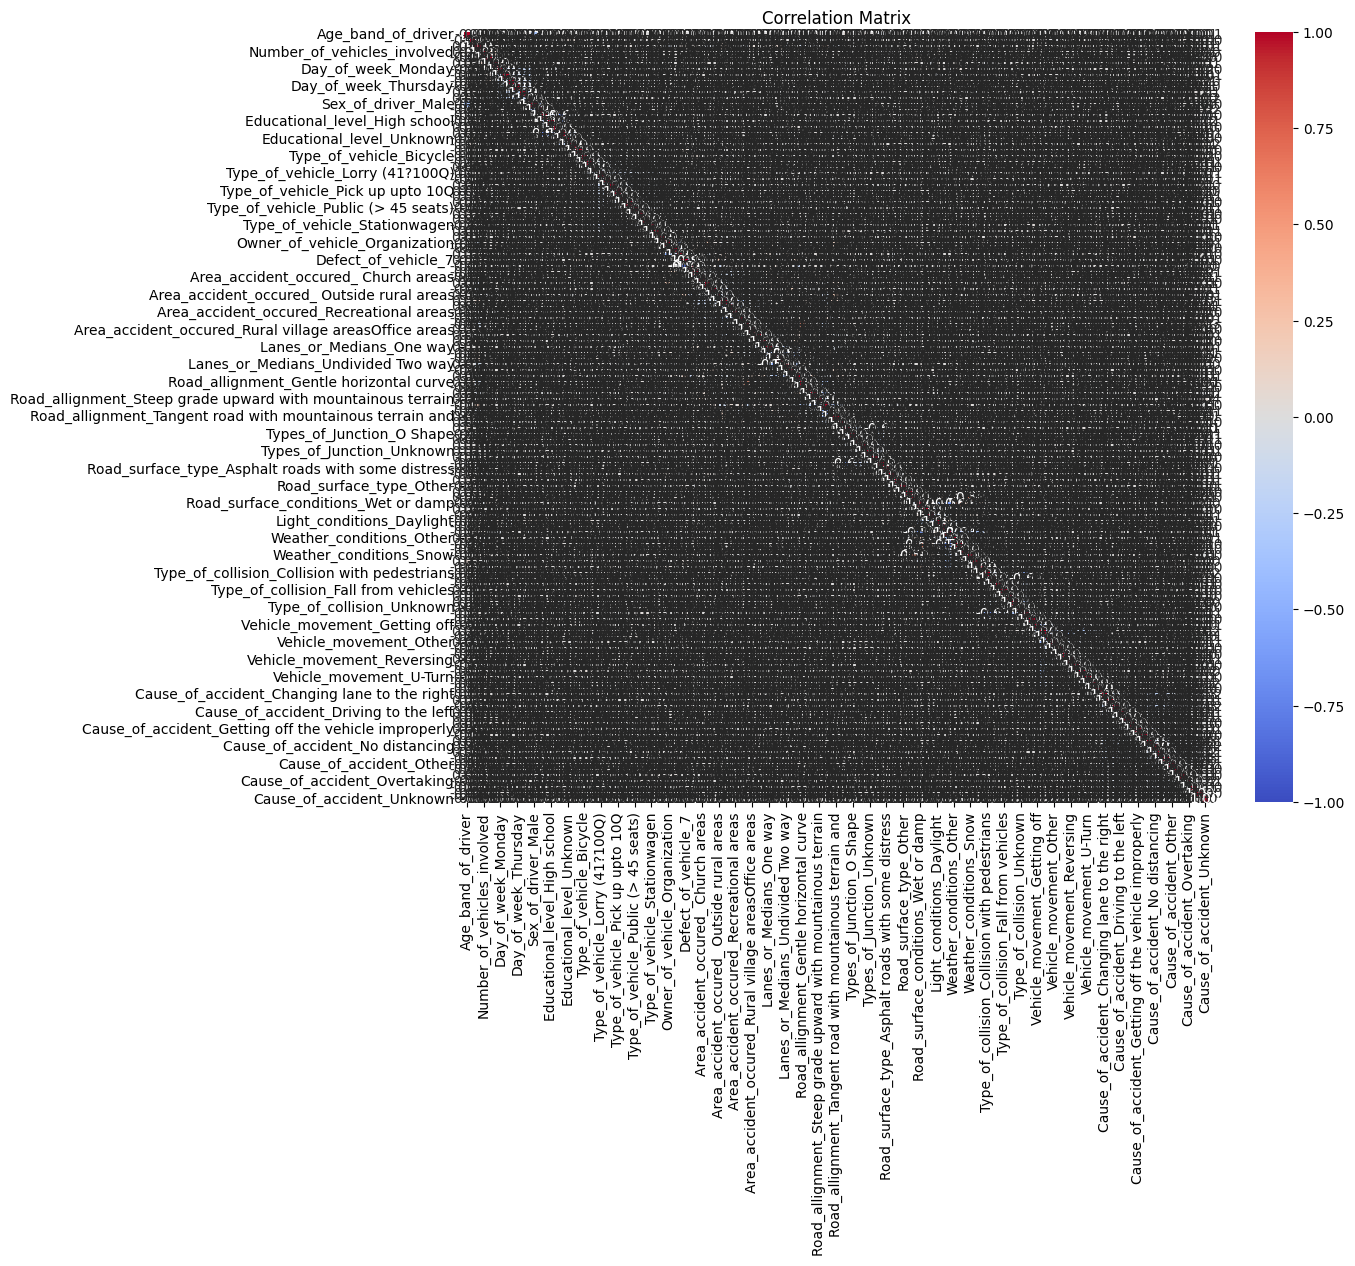

In [ ]:
# Calculate the correlation matrix
corr_matrix = dataset.corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

# Display the correlation of each feature with the target variable 'Degree Class'
degree_class_corr = corr_matrix['Accident_severity'].sort_values(ascending=True)


In [ ]:
# Set display option to print all rows
# pd.set_option('display.max_rows', None)

# Print the correlations with 'Degree'
print("\nCorrelation with Accident_severit:")
print(degree_class_corr)


Correlation with Accident_severit:
Number_of_casualties                      -0.045339
Light_conditions_Darkness - no lighting   -0.043421
Types_of_Junction_No junction             -0.035200
Weather_conditions_Normal                 -0.031890
Area_accident_occured_Residential areas   -0.028721
                                             ...   
Weather_conditions_Other                   0.028051
Day_of_week_Monday                         0.030887
Light_conditions_Daylight                  0.033136
Number_of_vehicles_involved                0.096023
Accident_severity                          1.000000
Name: Accident_severity, Length: 133, dtype: float64


In [ ]:
X = dataset.drop(columns=['Accident_severity'])
y = dataset['Accident_severity']

model = RandomForestClassifier()
model.fit(X, y)

feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)


In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feature_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
feature_scores

,0
Number_of_vehicles_involved,58.008563
Number_of_casualties,50.090592
Light_conditions_Darkness - no lighting,12.110760
Light_conditions_Daylight,11.713330
Types_of_Junction_No junction,9.737076
...,...
Vehicle_movement_Moving Backward,0.046269
Cause_of_accident_Changing lane to the right,0.045860
Road_surface_conditions_Wet or damp,0.031181
Vehicle_movement_Unknown,0.020641


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Train a RandomForestClassifier model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy for RandomForestClassifier model:", accuracy)


Model Accuracy for RandomForestClassifier model: 0.8396915584415584


In [ ]:
# Classification report
print("\nClassification Report for RandomForestClassifier model:")
print(classification_report(y_test, y_pred))


Classification Report for RandomForestClassifier model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        37
           1       0.78      0.02      0.04       363
           2       0.84      1.00      0.91      2064

    accuracy                           0.84      2464
   macro avg       0.54      0.34      0.32      2464
weighted avg       0.82      0.84      0.77      2464



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


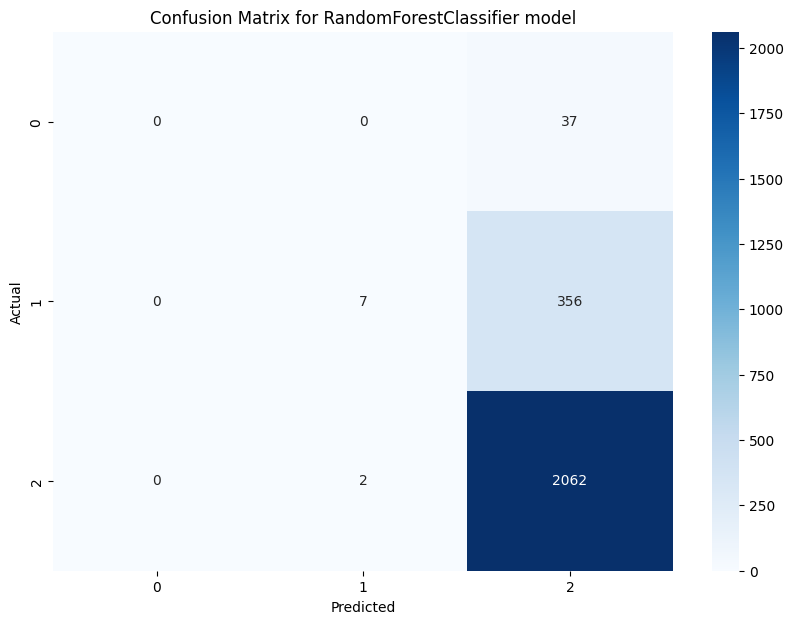

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for RandomForestClassifier model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:

# Train a LogisticRegression model
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print("\nLogistic Regression Model Accuracy:", accuracy_log_reg)


Logistic Regression Model Accuracy: 0.8376623376623377


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        37
           1       1.00      0.00      0.01       363
           2       0.84      1.00      0.91      2064

    accuracy                           0.84      2464
   macro avg       0.61      0.33      0.31      2464
weighted avg       0.85      0.84      0.76      2464



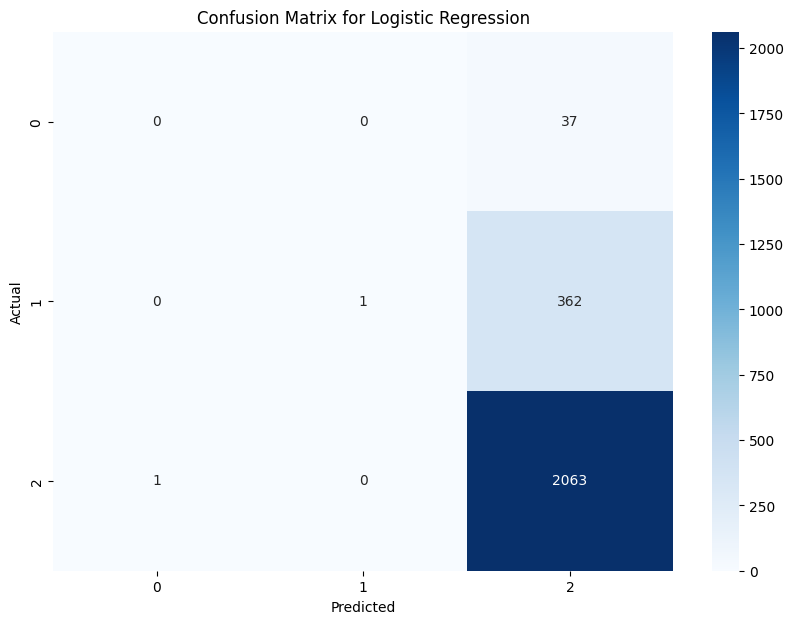

In [ ]:

# Classification report
print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_log_reg))

# Confusion matrix
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:

# Train a SVM model
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("\nSVM Model Accuracy:", accuracy_svm)


SVM Model Accuracy: 0.8376623376623377


In [ ]:
# Classification report
print("\nClassification Report for SVM:")
print(classification_report(y_test, y_pred_svm))


Classification Report for SVM:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        37
           1       0.00      0.00      0.00       363
           2       0.84      1.00      0.91      2064

    accuracy                           0.84      2464
   macro avg       0.28      0.33      0.30      2464
weighted avg       0.70      0.84      0.76      2464



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


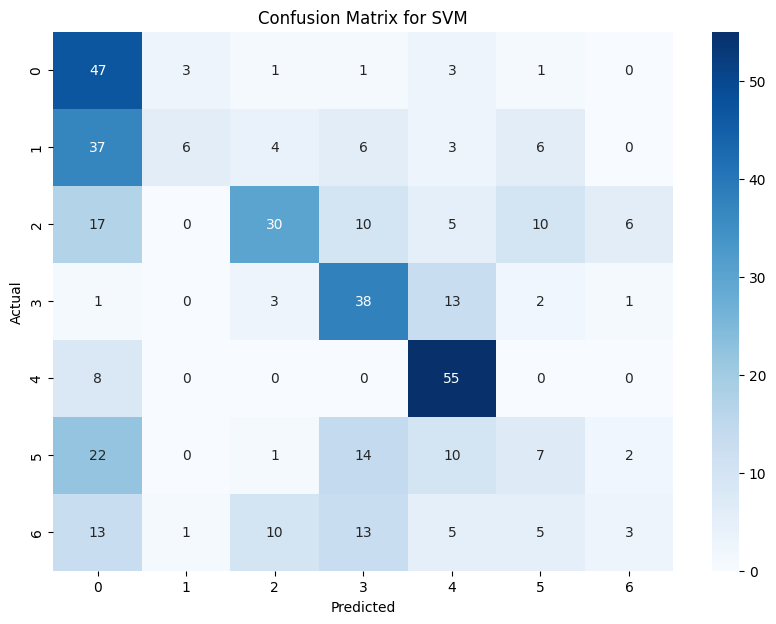

In [ ]:
# Confusion matrix
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Train a k-NN model
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("\nK-NN Model Accuracy:", accuracy_knn)


K-NN Model Accuracy: 0.7494089834515366


In [ ]:
# Classification report
print("\nClassification Report for K-NN:")
print(classification_report(y_test, y_pred_knn))




Classification Report for K-NN:
              precision    recall  f1-score   support

           0       0.68      0.84      0.75        56
           1       0.77      0.39      0.52        62
           2       0.71      0.83      0.77        78
           3       0.72      0.93      0.81        58
           4       0.94      1.00      0.97        63
           5       0.71      0.71      0.71        56
           6       0.71      0.48      0.57        50

    accuracy                           0.75       423
   macro avg       0.75      0.74      0.73       423
weighted avg       0.75      0.75      0.73       423



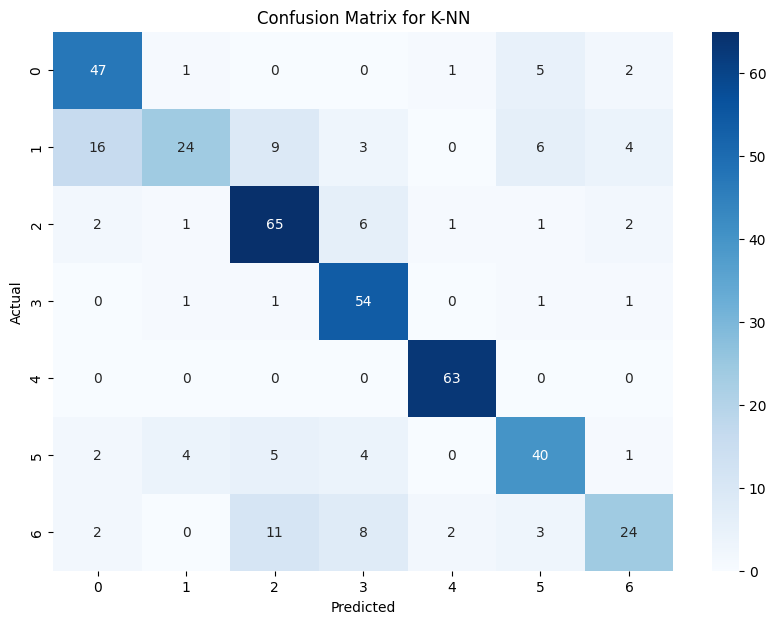

In [ ]:
# Confusion matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for K-NN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:


# Train a GradientBoosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print("\nGradient Boosting Model Accuracy:", accuracy_gb)



Gradient Boosting Model Accuracy: 0.8425324675324676


In [ ]:
# Classification report
print("\nClassification Report for Gradient Boosting:")
print(classification_report(y_test, y_pred_gb))


Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

           0       0.50      0.05      0.10        37
           1       0.83      0.04      0.08       363
           2       0.84      1.00      0.91      2064

    accuracy                           0.84      2464
   macro avg       0.73      0.36      0.36      2464
weighted avg       0.84      0.84      0.78      2464



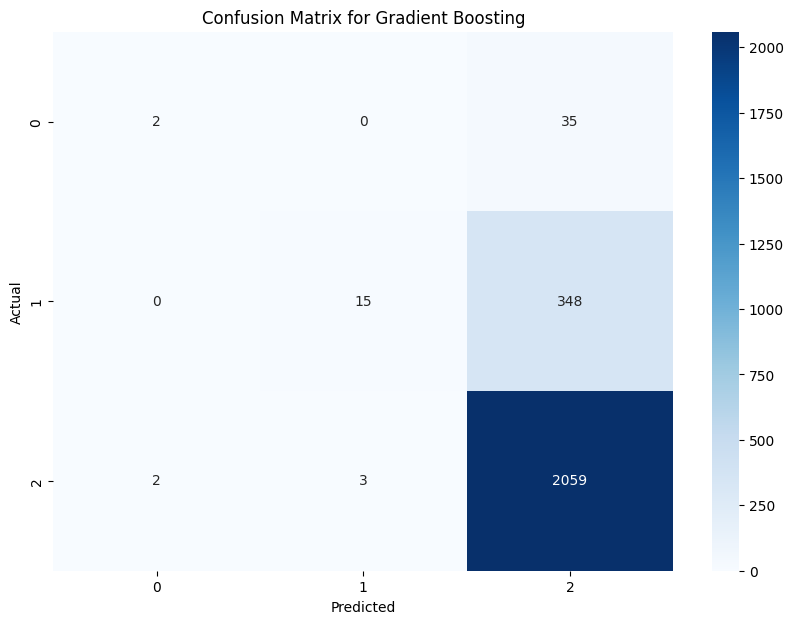

In [ ]:
# Confusion matrix
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:


# Train a Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("\nDecision Tree Model Accuracy:", accuracy_dt)


Decision Tree Model Accuracy: 0.7560876623376623


In [ ]:
# Classification report
print("\nClassification Report for Decision Tree:")
print(classification_report(y_test, y_pred_dt))


Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.28      0.24      0.26        37
           1       0.23      0.23      0.23       363
           2       0.86      0.86      0.86      2064

    accuracy                           0.76      2464
   macro avg       0.46      0.44      0.45      2464
weighted avg       0.76      0.76      0.76      2464



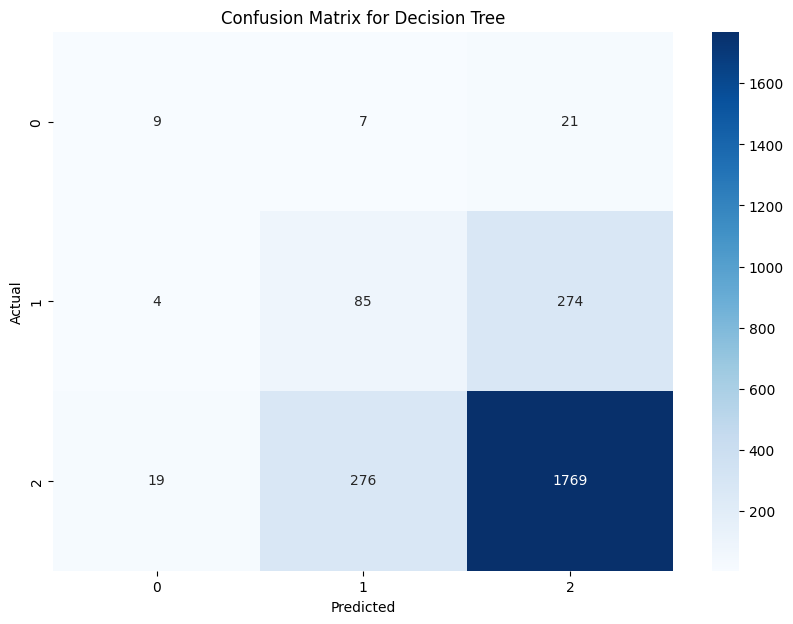

In [ ]:
# Confusion matrix
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
y_pred_dt

array([2, 2, 2, ..., 2, 2, 1])

In [ ]:
dataset['Accident_severity'].unique()

array([2, 1, 0])

In [ ]:
# Save the model and encoders
dump(gb_model, 'Accident_severity.joblib')
dump(one_hot_encoder, 'one_hot_encoder.joblib')
dump(label_encoders, 'label_encoders.joblib')
dump(scaler, 'scaler.joblib')

['scaler.joblib']